# 📘 Notebook: Visualización y Análisis Avanzado de Clientes

## 📌 Introducción
En este notebook analizaremos un conjunto de datos de clientes de seguros. Aplicaremos técnicas estadísticas y de visualización avanzadas con Seaborn, además de realizar pruebas de hipótesis e interpretación de resultados para construir narrativas basadas en los datos (storytelling).

### 📊 1. Importación de librerías y datos

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# Configuración de estilo
sns.set(style="whitegrid")
df = pd.read_csv("customer.csv")
df.head()


,Unnamed: 0,Customer,State,CustomerLifetimeValue,Response,Coverage,Education,EffectiveToDate,EmploymentStatus,Gender,...,MonthsSincePolicyInception,NumberofOpenComplaints,NumberofPolicies,PolicyType,Policy,RenewOfferType,SalesChannel,ClaimAmount,VehicleClass,VehicleSize
0,0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


### 📋 2. Análisis con Boxplots

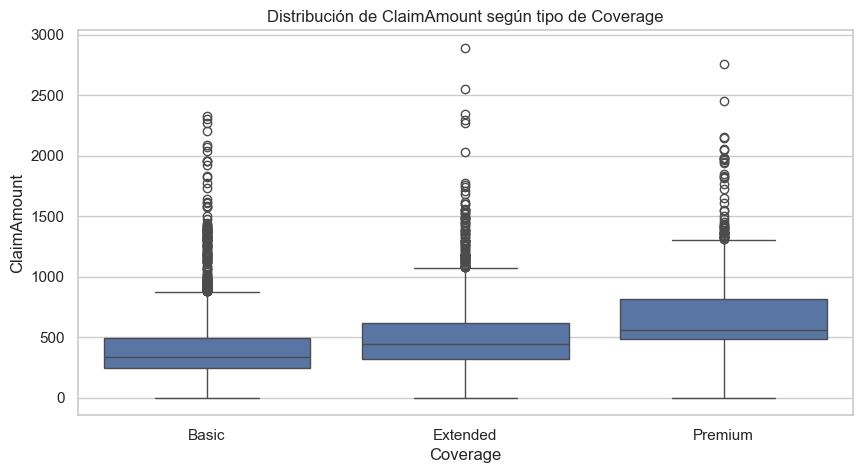

In [2]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Coverage', y='ClaimAmount', data=df)
plt.title("Distribución de ClaimAmount según tipo de Coverage")
plt.show()


#### 📌 Interpretar:

¿Cuál categoría muestra más outliers?

¿Qué podemos inferir sobre el riesgo y el tipo de cobertura?

### 🔥 3. Heatmap de Correlación

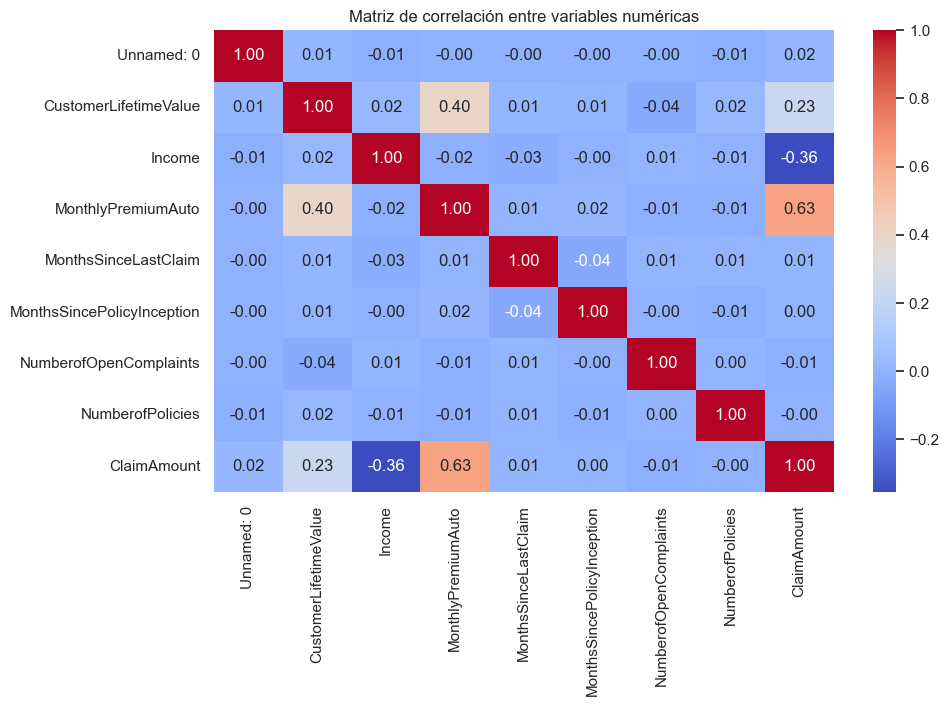

In [3]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()


#### 📌 Interpretar:

¿Qué variables están más correlacionadas con ClaimAmount?

¿Hay correlaciones inesperadas?

### 🎻 4. Violinplot

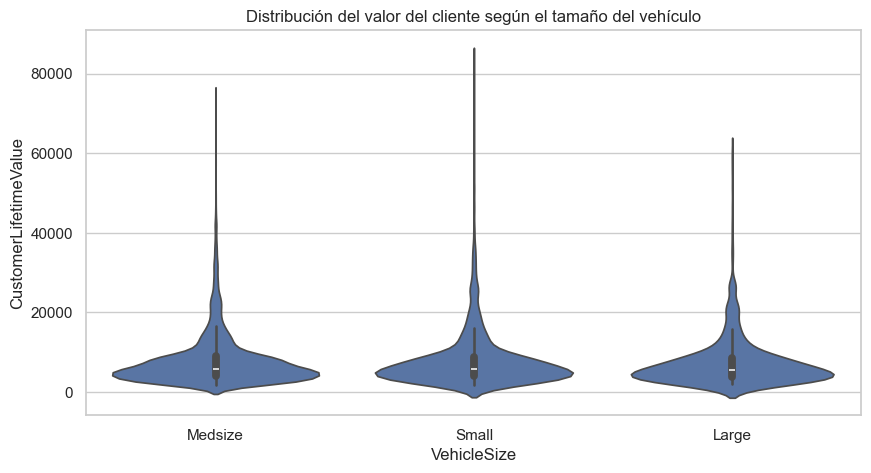

In [4]:
plt.figure(figsize=(10, 5))
sns.violinplot(x='VehicleSize', y='CustomerLifetimeValue', data=df)
plt.title("Distribución del valor del cliente según el tamaño del vehículo")
plt.show()


#### 📌 Preguntas:

¿Qué categoría muestra mayor concentración?

¿Qué sugiere esto sobre el perfil del cliente?

### 📈 5. Lineplot y FacetGrid

C:\Users\AyiGroup\AppData\Local\Temp\ipykernel_16728\1997096247.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['EffectiveToDate'] = pd.to_datetime(df['EffectiveToDate'])
C:\Users\AyiGroup\AppData\Local\Temp\ipykernel_16728\1997096247.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_sorted, x='EffectiveToDate', y='ClaimAmount', ci=None)


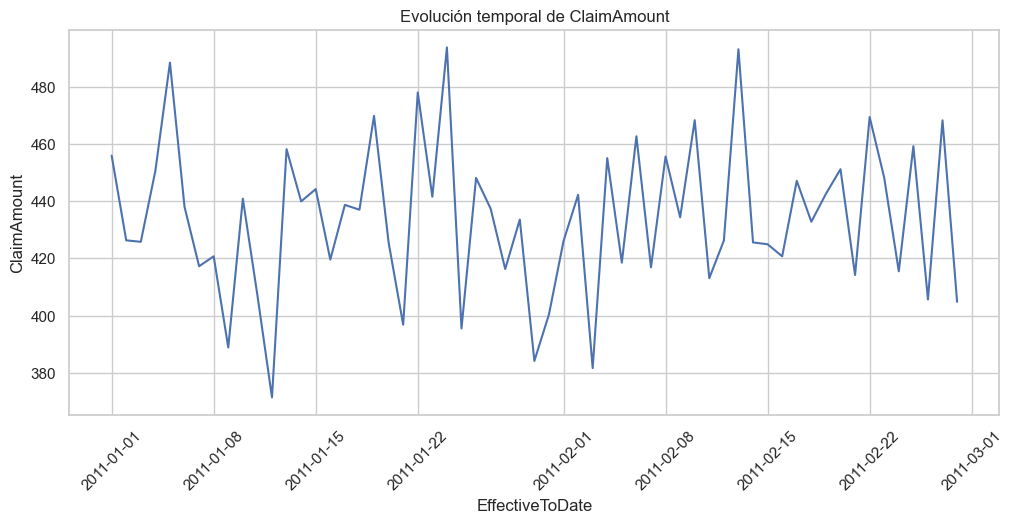

In [2]:
# Convertimos fechas
df['EffectiveToDate'] = pd.to_datetime(df['EffectiveToDate'])
df_sorted = df.sort_values("EffectiveToDate")

# Gráfico de línea
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_sorted, x='EffectiveToDate', y='ClaimAmount', ci=None)
plt.title("Evolución temporal de ClaimAmount")
plt.xticks(rotation=45)
plt.show()


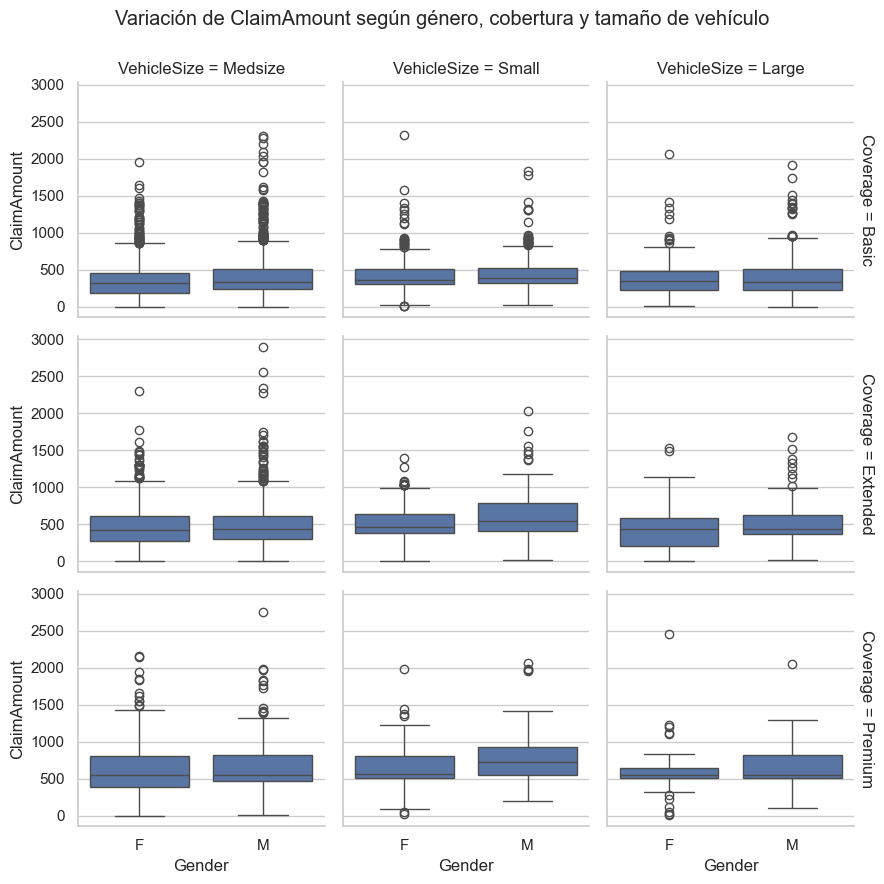

In [6]:
g = sns.FacetGrid(df, col="VehicleSize", row="Coverage", margin_titles=True, height=3)
g.map_dataframe(sns.boxplot, x="Gender", y="ClaimAmount")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Variación de ClaimAmount según género, cobertura y tamaño de vehículo")
plt.show()


### 🔍 6. Pairplot y relaciones entre variables

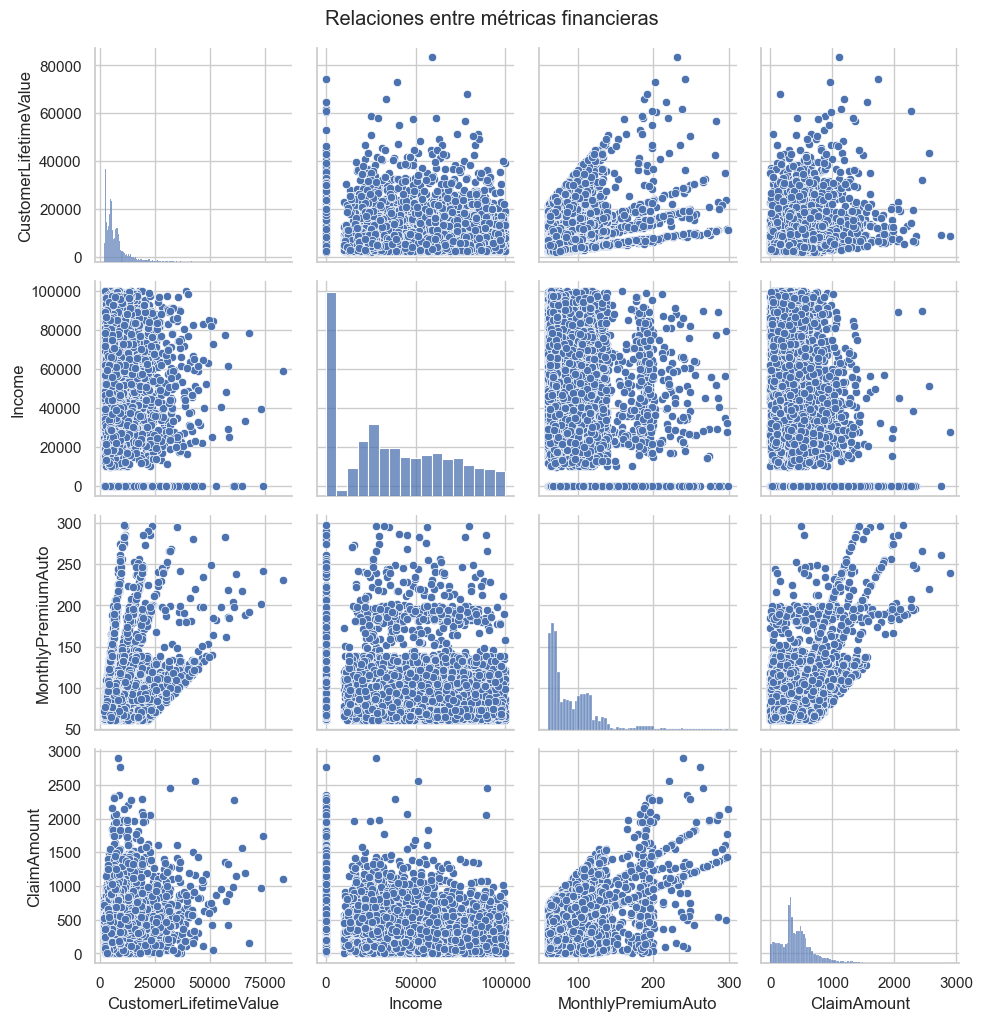

In [7]:
sns.pairplot(df[['CustomerLifetimeValue', 'Income', 'MonthlyPremiumAuto', 'ClaimAmount']])
plt.suptitle("Relaciones entre métricas financieras", y=1.02)
plt.show()


#### 📌 Analizar:

¿Qué relaciones visuales surgen?

¿Hay alguna correlación visible entre ingresos y siniestros?



### 📏 7. Intervalos de Confianza

In [8]:
sample = df['ClaimAmount'].dropna()
media = sample.mean()
std = sample.std()
n = len(sample)
conf_int = stats.norm.interval(0.95, loc=media, scale=std/np.sqrt(n))
print(f"Intervalo de confianza del 95% para ClaimAmount: {conf_int}")


Intervalo de confianza del 95% para ClaimAmount: (np.float64(428.1312969146246), np.float64(440.04629171116915))


#### 📌 Reflexión: ¿Qué significa este intervalo para un gerente de seguros?

### ❓ 8. Prueba de Hipótesis

##### Hipótesis: Los clientes con cobertura Premium tienen un monto promedio de siniestros diferente al de cobertura Básica.

In [3]:
basic = df[df['Coverage'] == 'Basic']['ClaimAmount']
premium = df[df['Coverage'] == 'Premium']['ClaimAmount']

t_stat, p_val = stats.ttest_ind(basic, premium, equal_var=False)
print(f"T-statistic: {t_stat}, p-value: {p_val}")


T-statistic: -19.179181383624748, p-value: 3.1560481079936134e-69


#### 📌 Conclusión:

¿Rechazamos H₀ al 5%?

¿Qué acciones de negocio se pueden derivar?

### 🧠 9. Storytelling con datos

#### Consejos:

- Destacar insights relevantes, no solo gráficos bonitos.

- Apoyarse en preguntas clave: ¿Qué? ¿Por qué? ¿Y ahora qué?

- Usar títulos claros y lenguaje no técnico para comunicar resultados.

### ✅ 10. Ejercicios Finales

🔹 Ejercicio 1:
Crear un gráfico que muestre cómo varía ClaimAmount según Coverage y VehicleSize, e interpretar qué conclusiones surgen sobre el perfil de riesgo.

🔹 Ejercicio 2:
Usar pairplot para encontrar relaciones ocultas entre al menos 3 variables del dataset. Escribir una conclusión al respecto.

🔹 Ejercicio 3:
Dado el dataset:

Construí al menos 3 visualizaciones con interpretación:

- 1 con análisis de outliers

- 1 con análisis de correlación

- 1 con una narrativa visual (storytelling)

🔹 Ejercicio 4:
Elaborar una visualización tipo “dashboard” con varios subplots (usar subplots o FacetGrid) que cuente una historia sobre los clientes más valiosos (CustomerLifetimeValue).